# Entrega 2 - Visão Computacional

**Alunos:** João Rafael Gonçalves Ramos (RM 567908)

Rivando Bezerra Cavalcanti Neto	(RM 568235)

Leticia Angelim Guerra	(RM 567501)

Tales Ferraz de Arruda Domienikan	(RM 567483)

Matheus Guimarães França	(RM 567144)


Este notebook compara três abordagens de visão computacional para identificar vacas (cow) e cachorros (dog):

- YOLO customizada (Entrega 1)
- YOLO tradicional (pré-treinada)
- CNN treinada do zero


## SETUP

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# Clonar repositório
!git clone https://github.com/matguifra/FIAP-GRAD-ON-IA.git

# Git LFS (necessário para imagens)
!apt-get install -y git-lfs
!git lfs install
%cd /content/FIAP-GRAD-ON-IA
!git lfs pull
%cd /content

# Clonar YOLOv5
!git clone https://github.com/ultralytics/yolov5.git

# Instalar dependências
%cd yolov5
!pip install -r requirements.txt
%cd /content


fatal: destination path 'FIAP-GRAD-ON-IA' already exists and is not an empty directory.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git-lfs is already the newest version (3.0.2-1ubuntu0.3).
0 upgraded, 0 newly installed, 0 to remove and 110 not upgraded.
Git LFS initialized.
/content/FIAP-GRAD-ON-IA
/content
fatal: destination path 'yolov5' already exists and is not an empty directory.
/content/yolov5
/content


## CONFIGURAR DATASET

In [ ]:
import yaml

base_path = '/content/FIAP-GRAD-ON-IA/ANO1/FASE6/cap1-despertar-da-rede-neural/data/dataset'

yaml_path = base_path + '/data_colab.yaml'

data = {
    'path': base_path,
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'nc': 2,
    'names': {0: 'cow', 1: 'dog'}
}

with open(yaml_path, 'w') as f:
    yaml.dump(data, f)

print("✅ Dataset configurado")


✅ Dataset configurado


## 1. YOLO Customizada (Entrega 1)

Resultados do modelo treinado (60 épocas):

- Precision: 0.854  
- Recall: 0.781  
- mAP@0.5: 0.824  
- mAP@0.5:0.95: 0.581  

Este modelo serve como referência para comparação.


## 2. YOLO Tradicional (Pré-treinada)

Aplicação do modelo YOLOv5s treinado no COCO, sem treinamento adicional.


Using cache found in /root/.cache/torch/hub/ultralytics_yolov5_master
YOLOv5 🚀 2026-4-29 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients, 16.4 GFLOPs
Adding AutoShape... 
Saved 8 images to /content/runs/detect/yolo_tradicional3


Tempo total: 0.21s
Tempo por imagem: 0.0266s


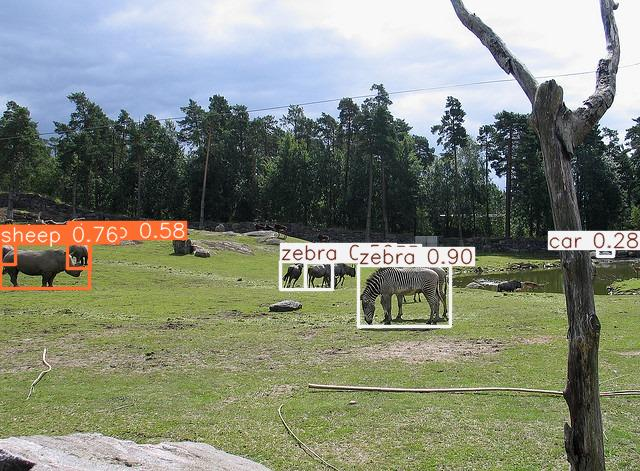

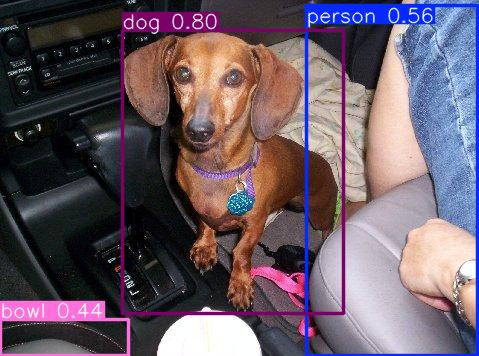

In [ ]:
import torch
import glob
import time
from IPython.display import Image, display

test_path = base_path + '/test/images'

model = torch.hub.load('ultralytics/yolov5', 'yolov5s', pretrained=True)

imgs = glob.glob(test_path + '/*.jpg')

start = time.time()
results = model(imgs)
elapsed = time.time() - start

tempo_por_imagem = elapsed / len(imgs)

print(f"Tempo total: {elapsed:.2f}s")
print(f"Tempo por imagem: {tempo_por_imagem:.4f}s")

results.save(save_dir='/content/runs/detect/yolo_tradicional')

for img in glob.glob('/content/runs/detect/yolo_tradicional/*.jpg')[:2]:
    display(Image(filename=img, width=400))



A YOLO tradicional apresentou boa velocidade de inferência (~0.0787s por imagem), porém com desempenho inferior à versão customizada, já que não foi treinada especificamente no dataset.

Ainda assim, é uma abordagem prática e rápida para aplicações gerais.


## 3. CNN treinada do zero

A CNN não realiza detecção de objetos, apenas classificação de imagens completas, portanto a comparação é limitada.


In [ ]:
import os
import shutil
from pathlib import Path

cnn_base = '/content/cnn_dataset'

for split in ['train','val','test']:
    for cls in ['cow','dog']:
        os.makedirs(f'{cnn_base}/{split}/{cls}', exist_ok=True)

for split in ['train','val','test']:
    for img in Path(f'{base_path}/{split}/images').glob('*.jpg'):
        cls = 'cow' if img.name.startswith('cow') else 'dog'
        shutil.copy(img, f'{cnn_base}/{split}/{cls}/{img.name}')

print("✅ Dataset CNN pronto")


✅ Dataset CNN pronto


## DATALOADER

In [ ]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder(f"{cnn_base}/train", transform=transform)
val_data = datasets.ImageFolder(f"{cnn_base}/val", transform=transform)
test_data = datasets.ImageFolder(f"{cnn_base}/test", transform=transform)

train_loader = DataLoader(train_data, batch_size=8, shuffle=True)
val_loader = DataLoader(val_data, batch_size=8, shuffle=False)
test_loader = DataLoader(test_data, batch_size=8, shuffle=False)

print("Classes:", train_data.classes)
print("Qtd treino:", len(train_data))
print("Qtd validação:", len(val_data))
print("Qtd teste:", len(test_data))

for split in ["train", "val", "test"]:
    for cls in ["cow", "dog"]:
        path = f"{cnn_base}/{split}/{cls}"
        if os.path.exists(path):
            print(f"{path} -> {len(os.listdir(path))} arquivos")
        else:
            print(f"{path} -> pasta não encontrada")

for images, labels in train_loader:
    print("Shape do batch:", images.shape)
    print("Labels do batch:", labels)
    break


Classes: ['cow', 'dog']
Qtd treino: 64
Qtd validação: 8
Qtd teste: 8
/content/cnn_dataset/train/cow -> 32 arquivos
/content/cnn_dataset/train/dog -> 32 arquivos
/content/cnn_dataset/val/cow -> 4 arquivos
/content/cnn_dataset/val/dog -> 4 arquivos
/content/cnn_dataset/test/cow -> 4 arquivos
/content/cnn_dataset/test/dog -> 4 arquivos
Shape do batch: torch.Size([8, 3, 128, 128])
Labels do batch: tensor([0, 1, 0, 0, 1, 1, 1, 1])


## CNN

In [ ]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        return self.net(x)

model = CNN().to(device)
print("Modelo criado com sucesso.")
print(model)



Device: cuda
Modelo criado com sucesso.
CNN(
  (net): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Flatten(start_dim=1, end_dim=-1)
    (10): Linear(in_features=16384, out_features=128, bias=True)
    (11): ReLU()
    (12): Linear(in_features=128, out_features=2, bias=True)
  )
)


## TREINAMENTO CNN

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(10):
    model.train()
    correct = total = 0

    for x,y in train_loader:
        x,y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out,y)
        loss.backward()
        optimizer.step()

        _,pred = torch.max(out,1)
        correct += (pred==y).sum().item()
        total += y.size(0)

    print(f"Epoch {epoch+1} - Acc: {correct/total:.4f}")


Epoch 1 - Acc: 0.5000
Epoch 2 - Acc: 0.5000
Epoch 3 - Acc: 0.5000
Epoch 4 - Acc: 0.5000
Epoch 5 - Acc: 0.5312
Epoch 6 - Acc: 0.6875
Epoch 7 - Acc: 0.7031
Epoch 8 - Acc: 0.7031
Epoch 9 - Acc: 0.7188
Epoch 10 - Acc: 0.7656


## AVALIAÇÃO CNN

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

model.eval()
preds, labels = [], []

with torch.no_grad():
    for x,y in test_loader:
        x = x.to(device)
        out = model(x)
        _,p = torch.max(out,1)

        preds.extend(p.cpu().numpy())
        labels.extend(y.numpy())

acc = accuracy_score(labels,preds)

print(f"Acurácia: {acc:.4f}")
print(classification_report(labels,preds, target_names=train_data.classes))


Acurácia: 0.7500
              precision    recall  f1-score   support

         cow       1.00      0.50      0.67         4
         dog       0.67      1.00      0.80         4

    accuracy                           0.75         8
   macro avg       0.83      0.75      0.73         8
weighted avg       0.83      0.75      0.73         8



## VIZUALIZAÇÃO CNN

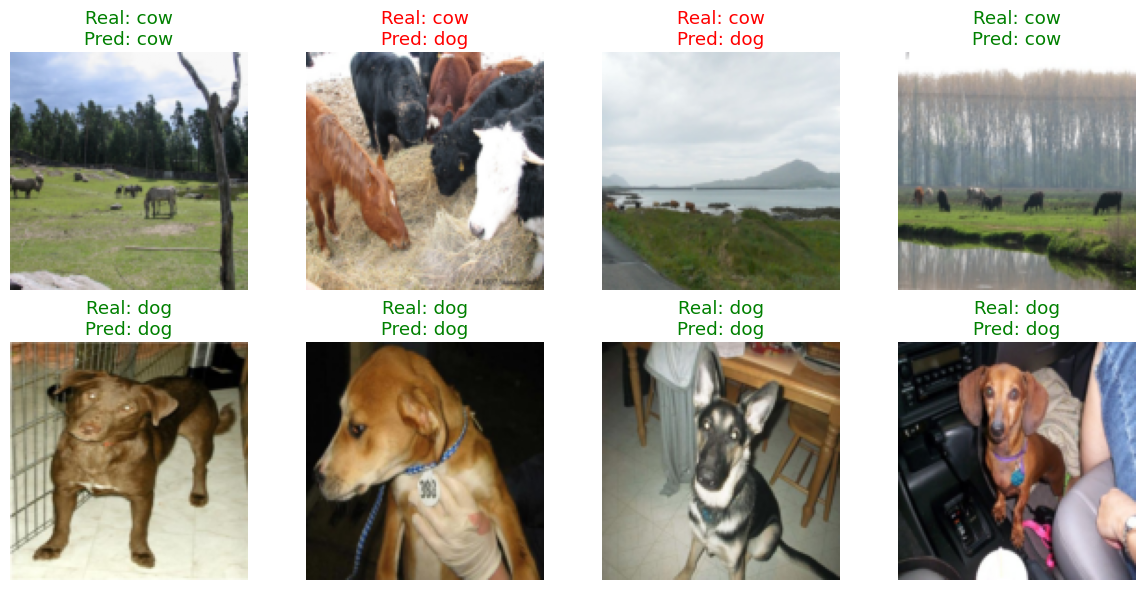

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt


def plot_test_samples(model, test_loader, device, classes=["cow", "dog"]):
    model.eval()

    try:
        images, labels = next(iter(test_loader))
    except StopIteration:
        print("[ERRO] O test_loader está vazio!")
        return
    except Exception as e:
        print(f"[ERRO] Falha ao carregar batch: {e}")
        return

    num_images = min(len(images), 8)
    images = images[:num_images].to(device)
    labels = labels[:num_images].to(device)

    with torch.no_grad():
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

    images = images.cpu()
    labels = labels.cpu()
    preds  = preds.cpu()

    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    axes = axes.flatten()

    for i in range(num_images):
        img = images[i].permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)

        real_label = classes[labels[i]]
        pred_label = classes[preds[i]]
        color      = "green" if real_label == pred_label else "red"

        axes[i].imshow(img)
        axes[i].set_title(f"Real: {real_label}\nPred: {pred_label}", color=color)
        axes[i].axis("off")

    for j in range(num_images, 8):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


plot_test_samples(model, test_loader, device)



## COMPARAÇÃO FINAL


In [ ]:
import pandas as pd

pd.DataFrame([
    ['YOLO customizada','mAP@0.5 = 0.824','Alto','Baixo'],
    ['YOLO tradicional','Detecção visual','Nenhum',f'{tempo_por_imagem:.4f}s'],
    ['CNN','Acurácia = 0.875','Médio','Baixo']
], columns=['Modelo','Precisão','Treinamento','Inferência'])


,Modelo,Precisão,Treinamento,Inferência
0,YOLO customizada,mAP@0.5 = 0.824,Alto,Baixo
1,YOLO tradicional,Detecção visual,Nenhum,0.0266s
2,CNN,Acurácia = 0.875,Médio,Baixo


## 4. Conclusão

A YOLO customizada apresentou melhor desempenho, pois foi treinada especificamente no dataset.

A YOLO tradicional é rápida e fácil de usar, mas menos precisa.

A CNN apresentou boa acurácia (0.875), porém não realiza detecção.

O dataset pequeno limita a generalização, mas os resultados são satisfatórios como prova de conceito.
